In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import math
import seaborn as sns

In [57]:
logs_dir = Path("all-logs/ablation-logs")
PLOT_DIR = Path("plots")
PLOT_DIR.mkdir(exist_ok=True)

csv_files = list(logs_dir.glob("SEWResNet*/*/*/*l.csv"))
csv_files

A_l_csvs = list(logs_dir.glob("*/*/*/*A_l.csv"))
O_l_csvs = list(logs_dir.glob("*/*/*/*O_l.csv"))

In [58]:
A_l_csvs

[PosixPath('all-logs/ablation-logs/SEWResNet_b16_T16_Ttrain12_steplr64_0.1_sgd_cnf_IAND/lr0.063/firing_rates/firing_rates_A_l.csv'),
 PosixPath('all-logs/ablation-logs/SEWResNet_b16_T16_Ttrain12_steplr64_0.1_sgd_cnf_AND/lr0.03/firing_rates/firing_rates_A_l.csv'),
 PosixPath('all-logs/ablation-logs/SEWResNet_b16_T16_Ttrain12_steplr64_0.1_sgd_cnf_ADD/lr0.001/firing_rates/firing_rates_A_l.csv'),
 PosixPath('all-logs/ablation-logs/SpikingResNet_b16_T16_Ttrain12_steplr64_0.1_sgd/lr0.1/firing_rates/firing_rates_A_l.csv')]

In [59]:
O_l_csvs

[PosixPath('all-logs/ablation-logs/SEWResNet_b16_T16_Ttrain12_steplr64_0.1_sgd_cnf_IAND/lr0.063/firing_rates/firing_rates_O_l.csv'),
 PosixPath('all-logs/ablation-logs/SEWResNet_b16_T16_Ttrain12_steplr64_0.1_sgd_cnf_AND/lr0.03/firing_rates/firing_rates_O_l.csv'),
 PosixPath('all-logs/ablation-logs/SEWResNet_b16_T16_Ttrain12_steplr64_0.1_sgd_cnf_ADD/lr0.001/firing_rates/firing_rates_O_l.csv'),
 PosixPath('all-logs/ablation-logs/SpikingResNet_b16_T16_Ttrain12_steplr64_0.1_sgd/lr0.1/firing_rates/firing_rates_O_l.csv')]

In [39]:
def plot_firing_rate_evolution_over_time(df_al, df_ol, plot_path):

    line_style_al = '-'  # Solid line for AL
    line_style_ol = '--'  # Dashed line for OL
    color_al = '#1f77b4'  # Blue
    color_ol = '#ff7f0e'  # Orange
    
    connect_f = df_al["connect_f"].unique()[0]

    if not isinstance(connect_f, str):
        network = "Spiking ResNet"
    else:
        network = f"SEW ResNet {connect_f}"
    
    fig, axs = plt.subplots(2, 4, figsize=(16, 6))
    for i in range(1, 8):
        row, col = divmod(i-1, 4)
        axs[row, col].plot(df_al['epoch'], df_al[f'block_{i}'], label='A_l', color=color_al, linestyle=line_style_al, linewidth=2)
        axs[row, col].plot(df_al['epoch'], df_ol[f'block_{i}'], label='O_l', alpha=0.8, color=color_ol, linestyle=line_style_ol, linewidth=2)
        axs[row, col].set_title(f'Block {i}')
        axs[row, col].grid(True)
        axs[row, col].legend()
        axs[row,col].set_xlabel("epoch")
        axs[row,col].set_ylabel("firing rate")
    axs[1, 3].axis('off')
    plt.suptitle(f"{network} Firing Rate Evolution Over Time")
    plt.tight_layout()
    plt.savefig(plot_path / f"{network} Firing Rate Evolution Over Time.png", dpi=300)
    plt.show()

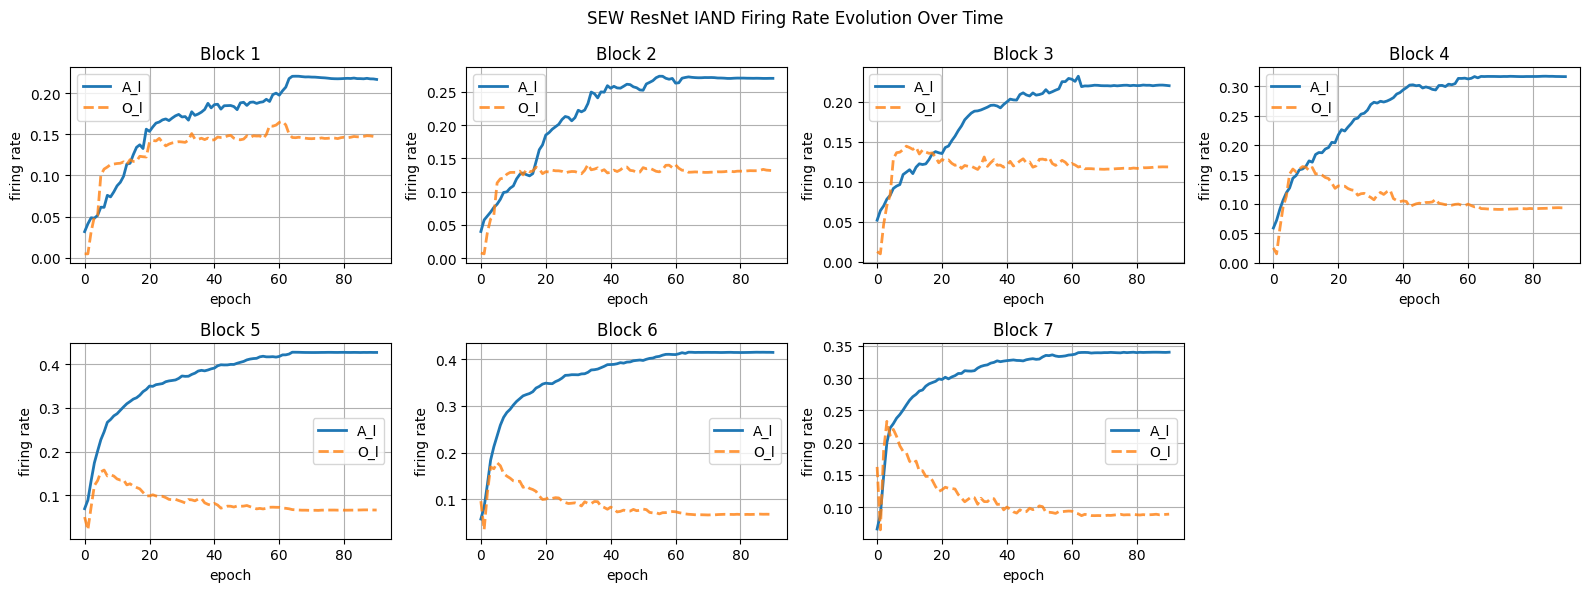

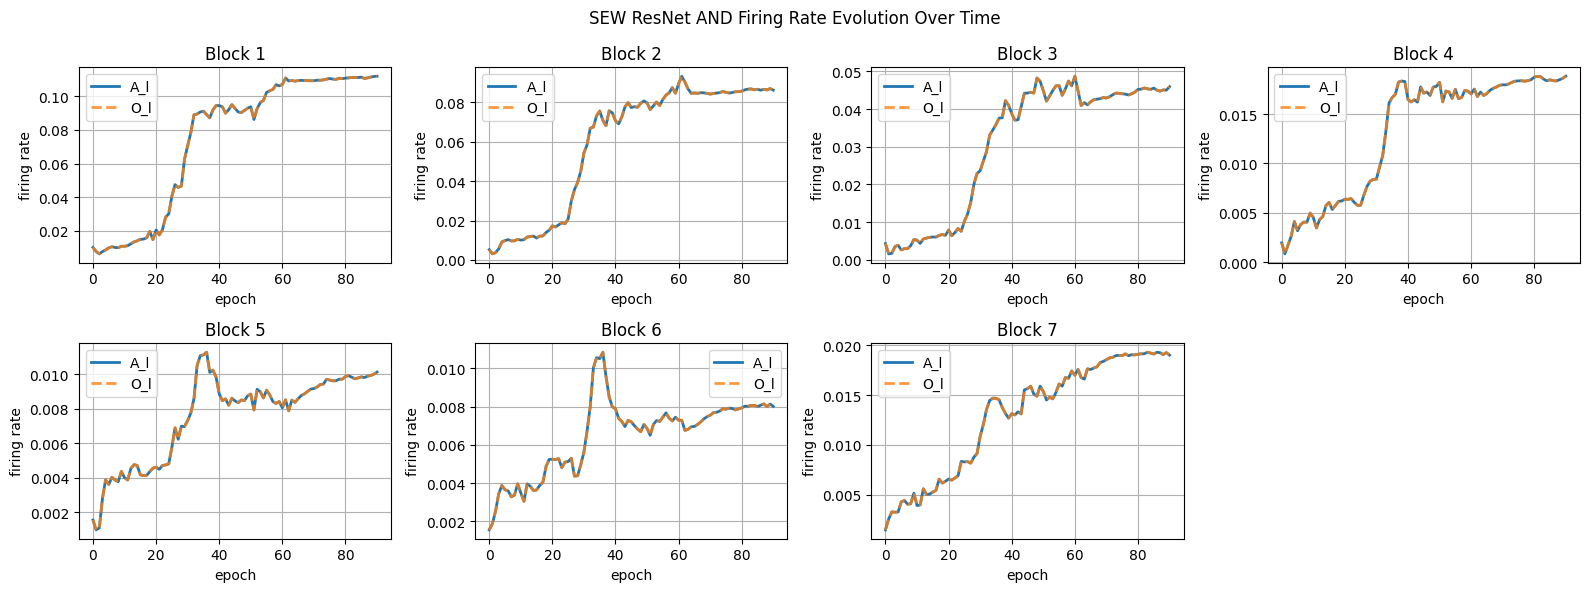

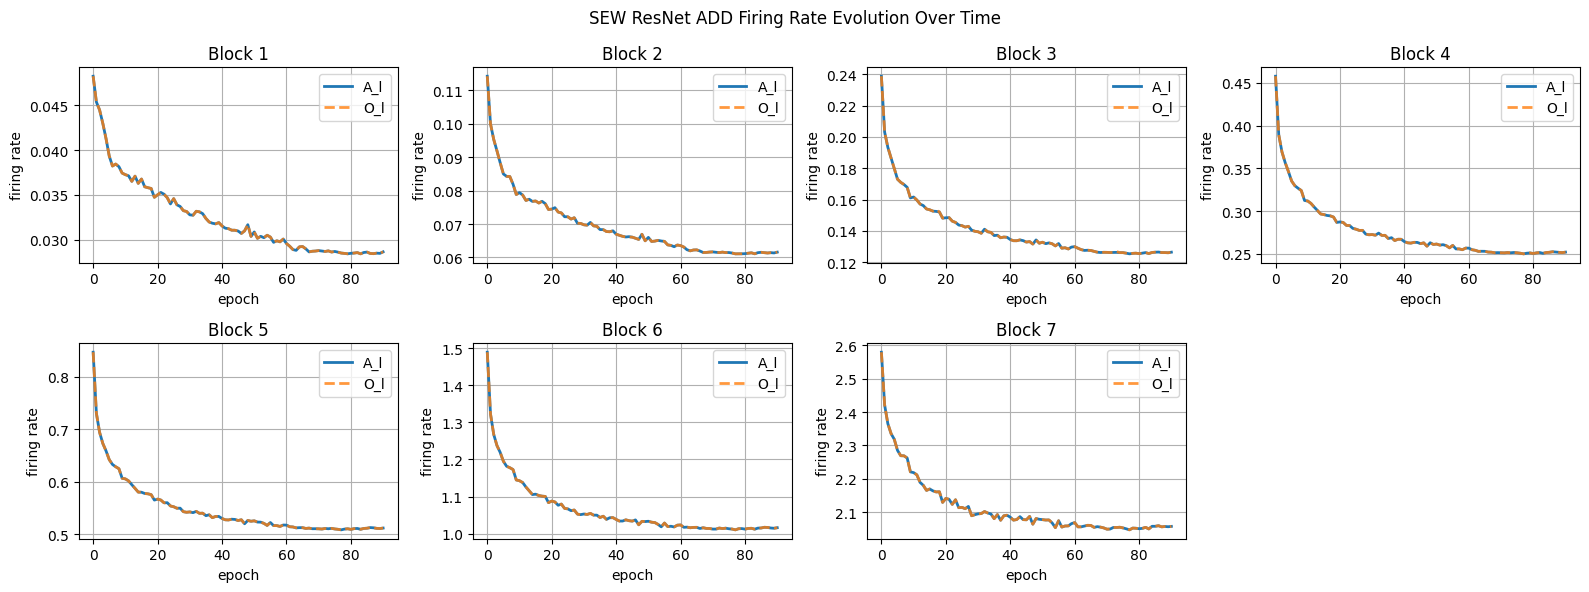

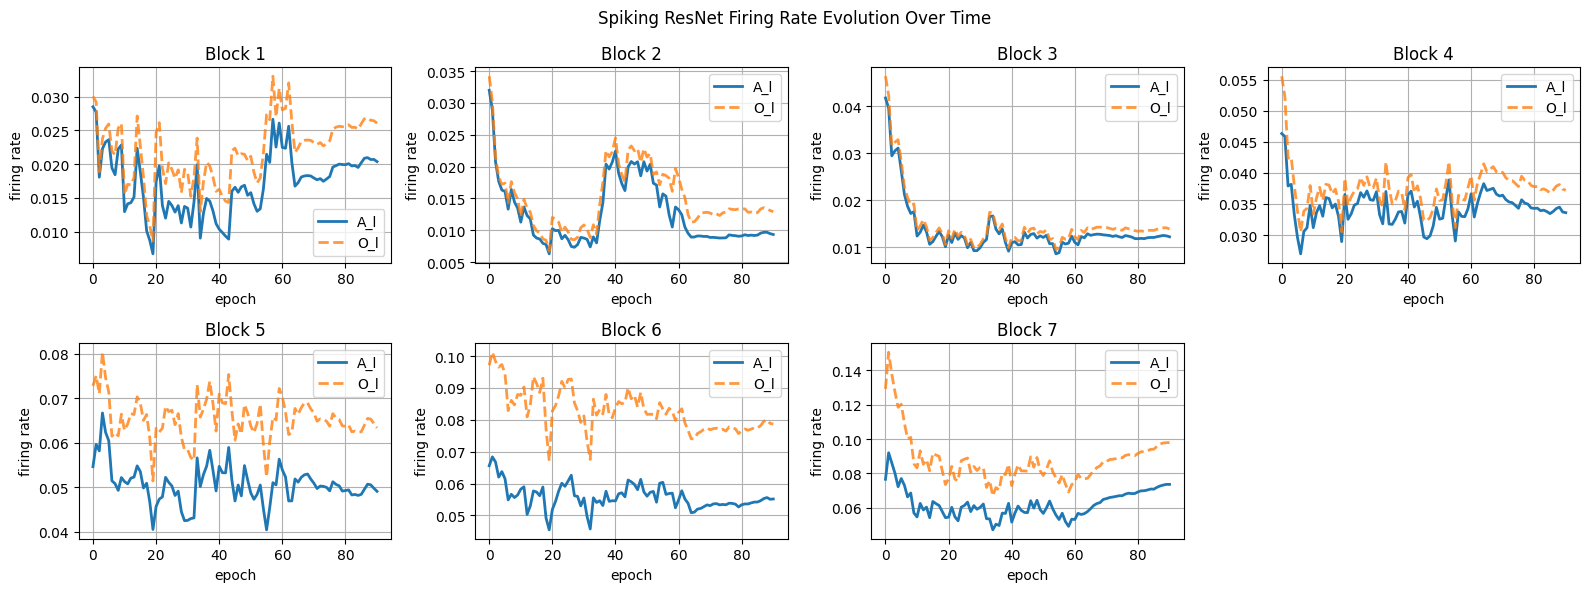

In [40]:
plot_path = PLOT_DIR / "firing_rate_evolution_over_time"
plot_path.mkdir(exist_ok=True)
for al_csv, ol_csv in zip(A_l_csvs, O_l_csvs):
    df_al = pd.read_csv(al_csv)
    df_ol = pd.read_csv(ol_csv)
    plot_firing_rate_evolution_over_time(df_al, df_ol, plot_path)

In [41]:
def plot_mean_firing_rate_per_block(df_al, df_ol, plot_path):
    blocks = [f'block_{i}' for i in range(1, 8)]

    # Compute mean firing rates across all epochs
    al_means = df_al[blocks].mean().values
    ol_means = df_ol[blocks].mean().values

    # Plot
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(range(1, 8), al_means, marker='o', linestyle='-', color='#1f77b4', label='A_l')
    ax.plot(range(1, 8), ol_means, marker='s', linestyle='--', color='#ff7f0e', label='O_l')
    ax.set_xticks(range(1, 8))
    ax.set_xlabel("Block Index (l)")
    ax.set_ylabel("Mean Firing Rate")
    connect_f = df_al["connect_f"].unique()[0]
    ax.set_title(f"Mean Firing Rate per Block ({connect_f})")
    ax.legend()
    ax.grid(True)

    # Save plot
    plot_path = Path(plot_path)
    plot_path.mkdir(parents=True, exist_ok=True)
    fig.savefig(plot_path / f"mean_firing_rate_per_block_{connect_f}.png", dpi=300)
    plt.close(fig)

In [42]:
plot_path = PLOT_DIR / "mean_firing_rate"
plot_path.mkdir(exist_ok=True)
for al_csv, ol_csv in zip(A_l_csvs, O_l_csvs):
    df_al = pd.read_csv(al_csv)
    df_ol = pd.read_csv(ol_csv)
    plot_mean_firing_rate_per_block(df_al, df_ol, plot_path)

In [43]:
def plot_mean_firing_rate_per_block_combined(df_als, df_ols, plot_path):
    blocks = [f'block_{i}' for i in range(1, 8)]

    # Define colors for each connection function
    color_map = {
        'ADD': '#1f77b4',
        'AND': '#2ca02c',
        'IAND': '#d62728',
    }

    # Extract connection function names
    connect_fs = [
        df_al["connect_f"].unique()[0] 
        if isinstance(df_al["connect_f"].unique()[0], str) 
        else "Spiking ResNet" 
        for df_al in df_als]

    # Plot setup
    fig, ax = plt.subplots(figsize=(9, 5))

    for df_al, df_ol, connect_f in zip(df_als, df_ols, connect_fs):
        al_means = df_al[blocks].mean().values
        ol_means = df_ol[blocks].mean().values

        color = color_map.get(connect_f, '#333333')  # Default color if not mapped

        # Plot A_l and O_l with distinct styles
        ax.plot(range(1, 8), al_means, marker='o', linestyle='-', color=color, linewidth=2,
                label=f'{connect_f} $A^l$')
        ax.plot(range(1, 8), ol_means, marker='s', linestyle='--', color=color, linewidth=2,
                label=f'{connect_f} $O^l$')

    # Axis formatting
    ax.set_xticks(range(1, 8))
    ax.set_xlabel("Block Index (l)")
    ax.set_ylabel("Mean Firing Rate")
    ax.set_title("Mean Firing Rate per Block")
    ax.grid(True)
    ax.legend()

    # Save plot
    plot_path = Path(plot_path)
    plot_path.mkdir(parents=True, exist_ok=True)
    fig.savefig(plot_path / "mean_firing_rate_per_block_combined.png", dpi=300)
    plt.show(fig)

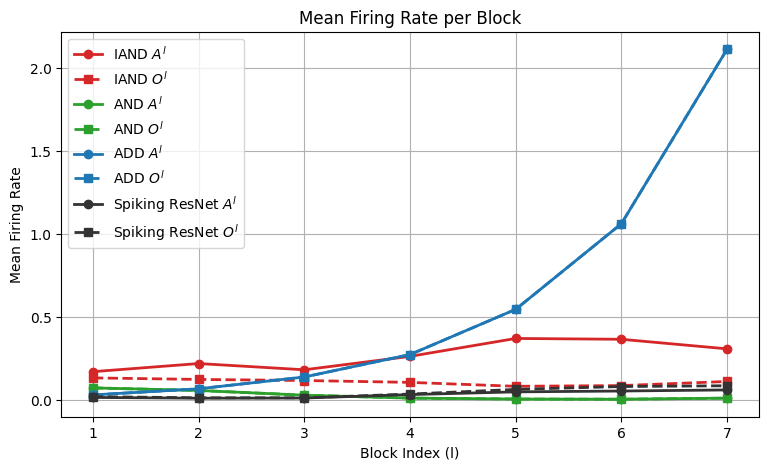

In [44]:
plot_path = PLOT_DIR / "mean_firing_rate"
plot_path.mkdir(exist_ok=True)

df_als = [pd.read_csv(al_csv) for al_csv in A_l_csvs]
df_ols = [pd.read_csv(ol_csv) for ol_csv in O_l_csvs]
plot_mean_firing_rate_per_block_combined(df_als, df_ols, plot_path)

In [45]:
def plot_mean_firing_rate_per_block_al_or_ol_only(df_als, plot_path, al=True):
    blocks = [f'block_{i}' for i in range(1, 8)]

    # Define colors for each connection/network type
    color_map = {
        'Spiking': '#1f77b4',
        'ADD': '#ff7f0e',
        'AND': '#d62728',
        'IAND': '#9467bd',
    }

    # Extract connection function labels from DataFrames
    connect_fs = [
        df_al["connect_f"].unique()[0] 
        if isinstance(df_al["connect_f"].unique()[0], str) 
        else "Spiking" 
        for df_al in df_als]

    fig, ax = plt.subplots(figsize=(8, 5))

    for df_al, connect_f in zip(df_als, connect_fs):
        al_means = df_al[blocks].mean().values
        color = color_map.get(connect_f, '#333333')
        ax.plot(range(7), al_means, marker='o', linestyle='-', color=color, linewidth=2, label=f"{'SEW ' + connect_f if connect_f!="Spiking" else connect_f}")

    ax.set_xticks(range(7))
    ax.set_xticklabels([str(i) for i in range(7)])
    ax.set_xlabel("block index $l$")
    ax.set_ylabel("firing rate")
    ax.set_title(f"Firing rates of ${'A^l' if al else 'O^l'}$ in each block")
    ax.legend()
    ax.grid(True)

    plot_path = Path(plot_path)
    plot_path.mkdir(parents=True, exist_ok=True)
    fig.savefig(plot_path / f"firing_rates_{'al' if al else 'ol'}_per_block.png", dpi=300)
    plt.show()

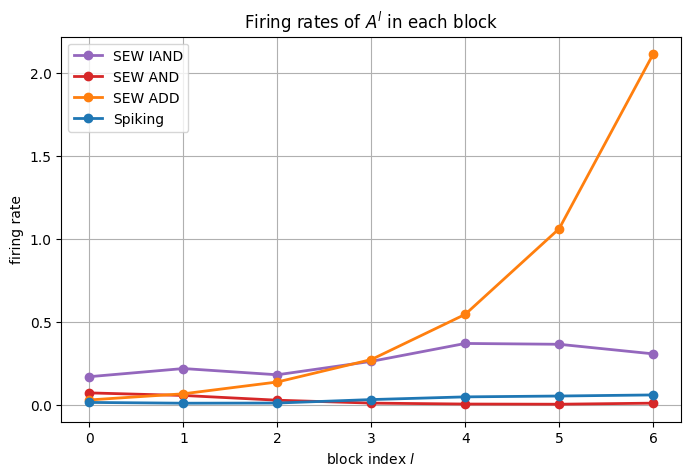

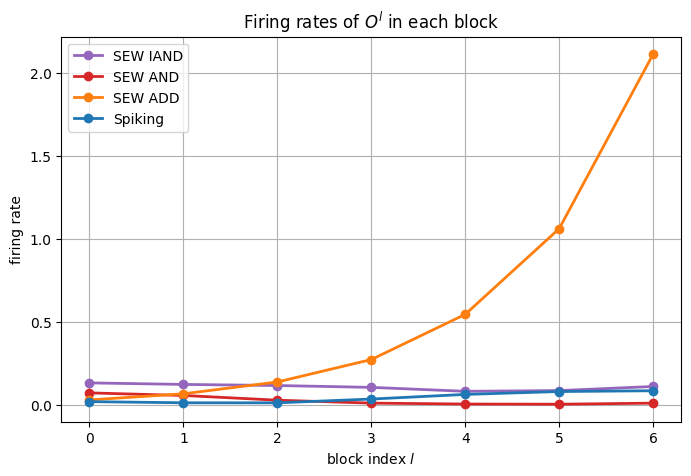

In [46]:
plot_path = PLOT_DIR / "mean_firing_rate_as_per_paper"
plot_path.mkdir(exist_ok=True)

df_als = [pd.read_csv(al_csv) for al_csv in A_l_csvs]
df_ols = [pd.read_csv(ol_csv) for ol_csv in O_l_csvs]
plot_mean_firing_rate_per_block_al_or_ol_only(df_als, plot_path, al=True)
plot_mean_firing_rate_per_block_al_or_ol_only(df_ols, plot_path, al=False)

In [49]:
A_l_csvs[:2]+A_l_csvs[3:]

[PosixPath('ablation-logs/SEWResNet_b16_T16_Ttrain12_steplr64_0.1_sgd_cnf_IAND/lr0.063/firing_rates/firing_rates_A_l.csv'),
 PosixPath('ablation-logs/SEWResNet_b16_T16_Ttrain12_steplr64_0.1_sgd_cnf_AND/lr0.03/firing_rates/firing_rates_A_l.csv'),
 PosixPath('ablation-logs/SpikingResNet_b16_T16_Ttrain12_steplr64_0.1_sgd/lr0.1/firing_rates/firing_rates_A_l.csv')]

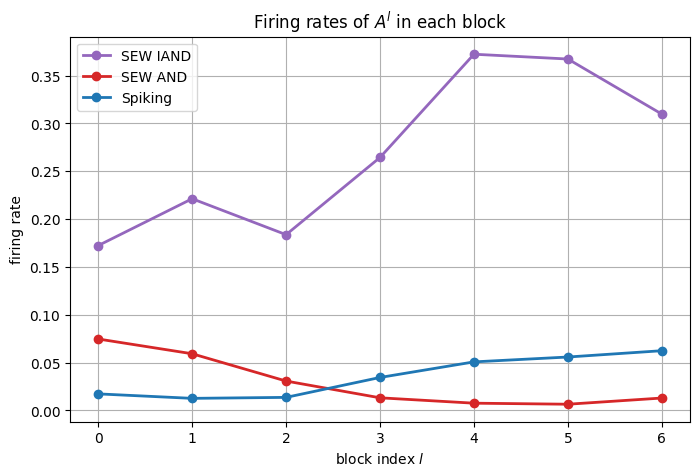

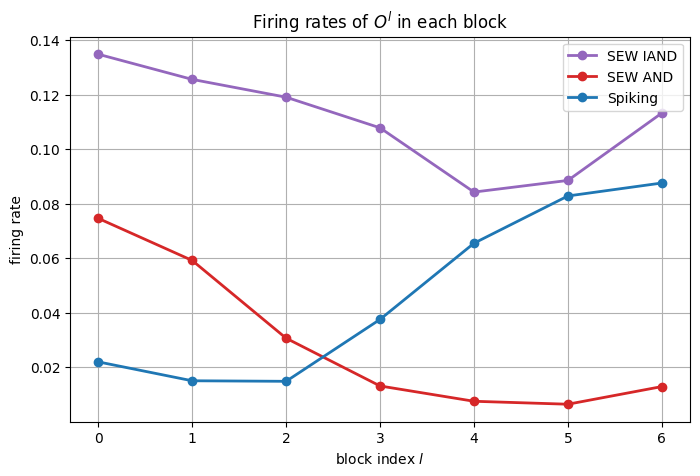

In [50]:
plot_path = PLOT_DIR / "mean_firing_rate_as_per_paper_separate"
plot_path.mkdir(exist_ok=True)

plot_path = plot_path / "no_add"
plot_path.mkdir(exist_ok=True)

df_als = [pd.read_csv(al_csv) for al_csv in A_l_csvs[:2]+A_l_csvs[3:]]
df_ols = [pd.read_csv(ol_csv) for ol_csv in O_l_csvs[:2]+O_l_csvs[3:]]
plot_mean_firing_rate_per_block_al_or_ol_only(df_als, plot_path, al=True)
plot_mean_firing_rate_per_block_al_or_ol_only(df_ols, plot_path, al=False)

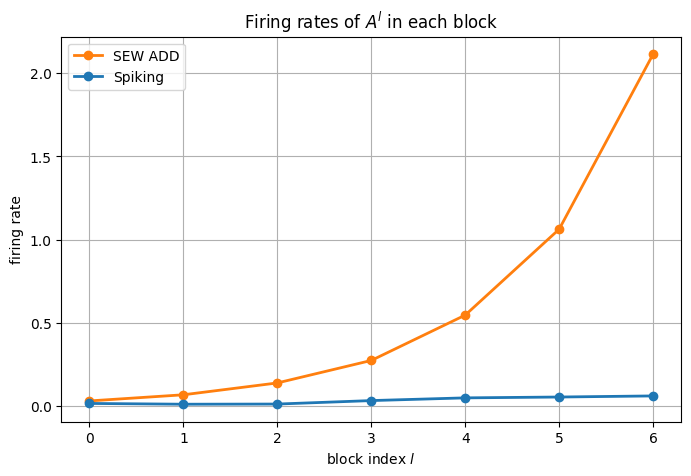

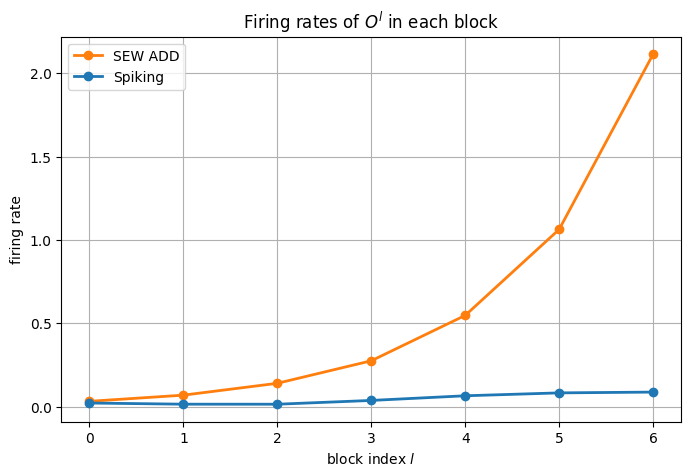

In [52]:
plot_path = PLOT_DIR / "mean_firing_rate_as_per_paper_separate"
plot_path.mkdir(exist_ok=True)

plot_path = plot_path / "only_add"
plot_path.mkdir(exist_ok=True)

df_als = [pd.read_csv(al_csv) for al_csv in A_l_csvs[2:]]
df_ols = [pd.read_csv(ol_csv) for ol_csv in O_l_csvs[2:]]
plot_mean_firing_rate_per_block_al_or_ol_only(df_als, plot_path, al=True)
plot_mean_firing_rate_per_block_al_or_ol_only(df_ols, plot_path, al=False)

In [16]:
def plot_early_vs_late_firing_rate_evolution(df_als, df_ols, plot_path):
    # Define block ranges
    early_blocks = [f'block_{i}' for i in range(1, 4)]
    late_blocks = [f'block_{i}' for i in range(5, 8)]

    # Define colors for A_l and O_l lines
    color_map = {
        'A_l early': '#1f77b4',
        'A_l late': '#1f77b4',
        'O_l early': '#ff7f0e',
        'O_l late': '#ff7f0e',
    }

    # Loop over each model's DataFrame pair (A_l, O_l)
    for df_al, df_ol in zip(df_als, df_ols):
        label = df_al["connect_f"].unique()[0]
        if not isinstance(label, str):
            label = "Spiking"

        # Compute average firing rate across early and late blocks
        df_al['early_mean'] = df_al[[*early_blocks]].mean(axis=1)
        df_al['late_mean'] = df_al[[*late_blocks]].mean(axis=1)
        df_ol['early_mean'] = df_ol[[*early_blocks]].mean(axis=1)
        df_ol['late_mean'] = df_ol[[*late_blocks]].mean(axis=1)

        # Set up plot
        fig, ax = plt.subplots(figsize=(9, 5))

        # Plot A_l
        ax.plot(df_al['epoch'], df_al['early_mean'], linestyle='-', color=color_map['A_l early'], linewidth=2, label=r"$A^l$ early")
        ax.plot(df_al['epoch'], df_al['late_mean'], linestyle='--', color=color_map['A_l late'], linewidth=2, label=r"$A^l$ late")

        # Plot O_l
        ax.plot(df_ol['epoch'], df_ol['early_mean'], linestyle='-', color=color_map['O_l early'], alpha=0.6, linewidth=2, label=r"$O^l$ early")
        ax.plot(df_ol['epoch'], df_ol['late_mean'], linestyle='--', color=color_map['O_l late'], alpha=0.6, linewidth=2, label=r"$O^l$ late")

        # Formatting
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Mean Firing Rate")
        ax.set_title(f"Early vs. Late Block Firing Rate Over Time ({label})")
        ax.grid(True)
        ax.legend()

        # Save
        save_dir = Path(plot_path)
        save_dir.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_dir / f"early_vs_late_firing_rate_evolution_{label}.png", dpi=300)
        plt.show()
        plt.close(fig)

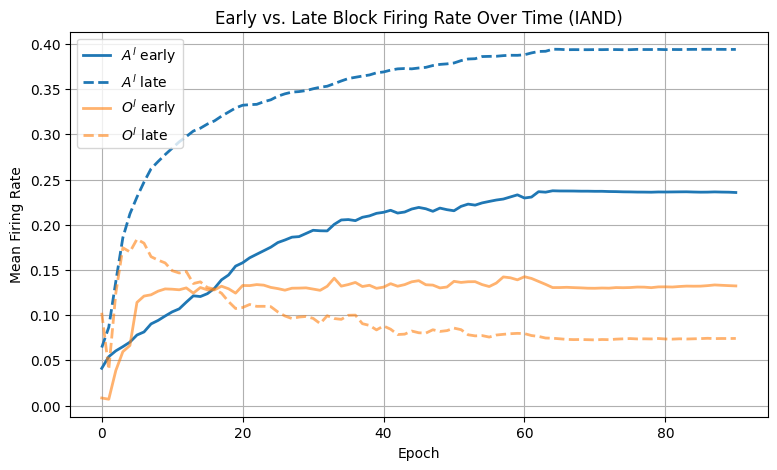

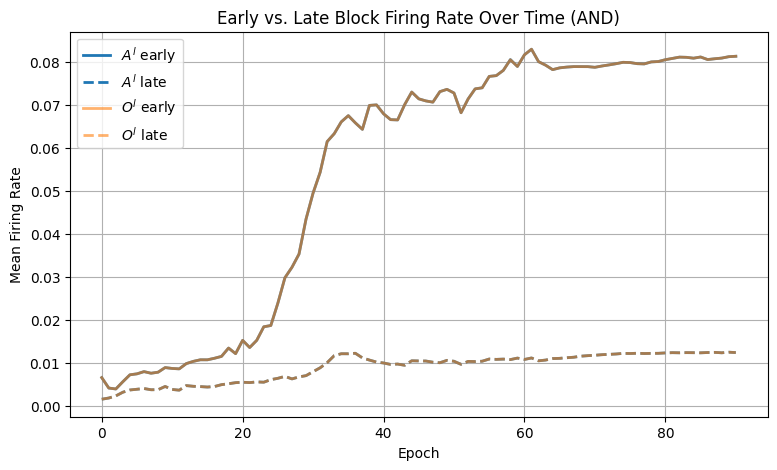

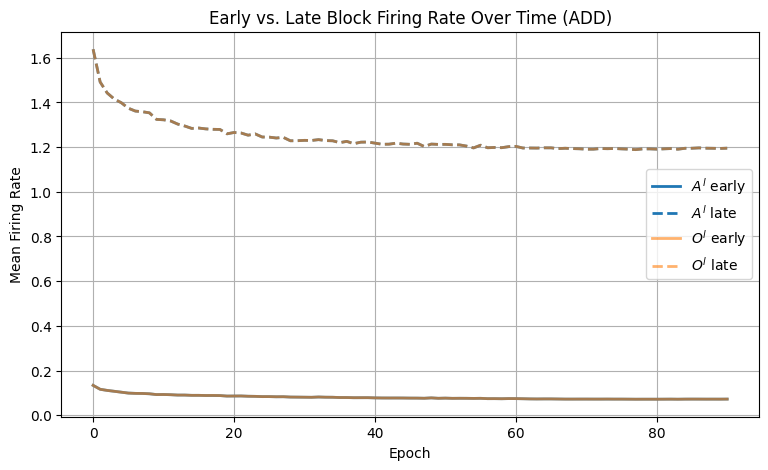

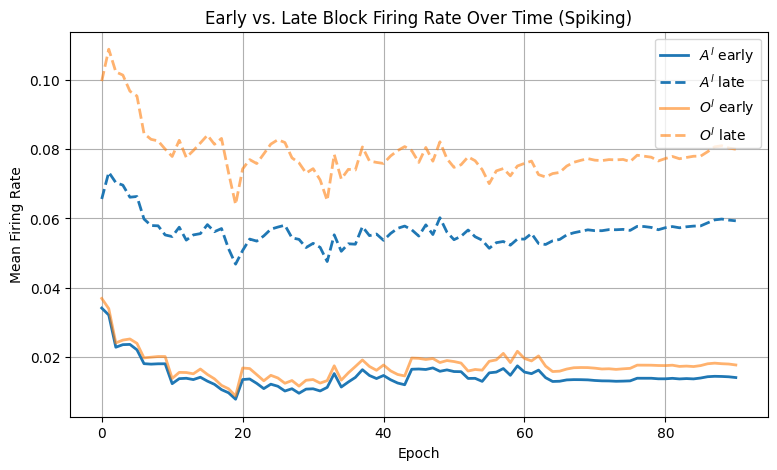

In [17]:
plot_path = PLOT_DIR / "early_vs_late_firing_rate_evolution"
plot_path.mkdir(exist_ok=True)

df_als = [pd.read_csv(al_csv) for al_csv in A_l_csvs]
df_ols = [pd.read_csv(ol_csv) for ol_csv in O_l_csvs]
plot_early_vs_late_firing_rate_evolution(df_als, df_ols, plot_path)

In [19]:
def plot_al_ol_evolution_dual_subplot(df_als, df_ols, plot_path):
    blocks = [f'block_{i}' for i in range(1, 8)]
    color_map = plt.cm.get_cmap('tab10', len(blocks))

    for df_al, df_ol in zip(df_als, df_ols):
        label = df_al["connect_f"].unique()[0]
        if not isinstance(label, str):
            label = "Spiking"

        fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

        # Top: A^l evolution for all blocks
        for i, block in enumerate(blocks, start=1):
            axs[0].plot(df_al['epoch'], df_al[block], label=f"$A^l$ Block {i}", color=color_map(i - 1), linewidth=2)
        axs[0].set_title(f"{label}: $A^l$ Firing Rate Evolution Over Time")
        axs[0].set_ylabel("Firing Rate")
        axs[0].grid(True)
        axs[0].legend(loc="upper right", ncol=4, fontsize="small")

        # Bottom: O^l evolution for all blocks
        for i, block in enumerate(blocks, start=1):
            axs[1].plot(df_ol['epoch'], df_ol[block], label=f"$O^l$ Block {i}", color=color_map(i - 1), linestyle='--', linewidth=2)
        axs[1].set_title(f"{label}: $O^l$ Firing Rate Evolution Over Time")
        axs[1].set_xlabel("Epoch")
        axs[1].set_ylabel("Firing Rate")
        axs[1].grid(True)
        axs[1].legend(loc="upper right", ncol=4, fontsize="small")

        plt.suptitle(f"{label} Firing Rate Evolution Over Time", fontsize=14)
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])

        save_dir = Path(plot_path)
        save_dir.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_dir / f"firing_rate_evolution_dual_{label}.png", dpi=300)
        plt.show()
        plt.close(fig)

/var/folders/yy/f08jrfk55s3_yrjg0s_jfggc0000gn/T/ipykernel_3801/3702104623.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap('tab10', len(blocks))


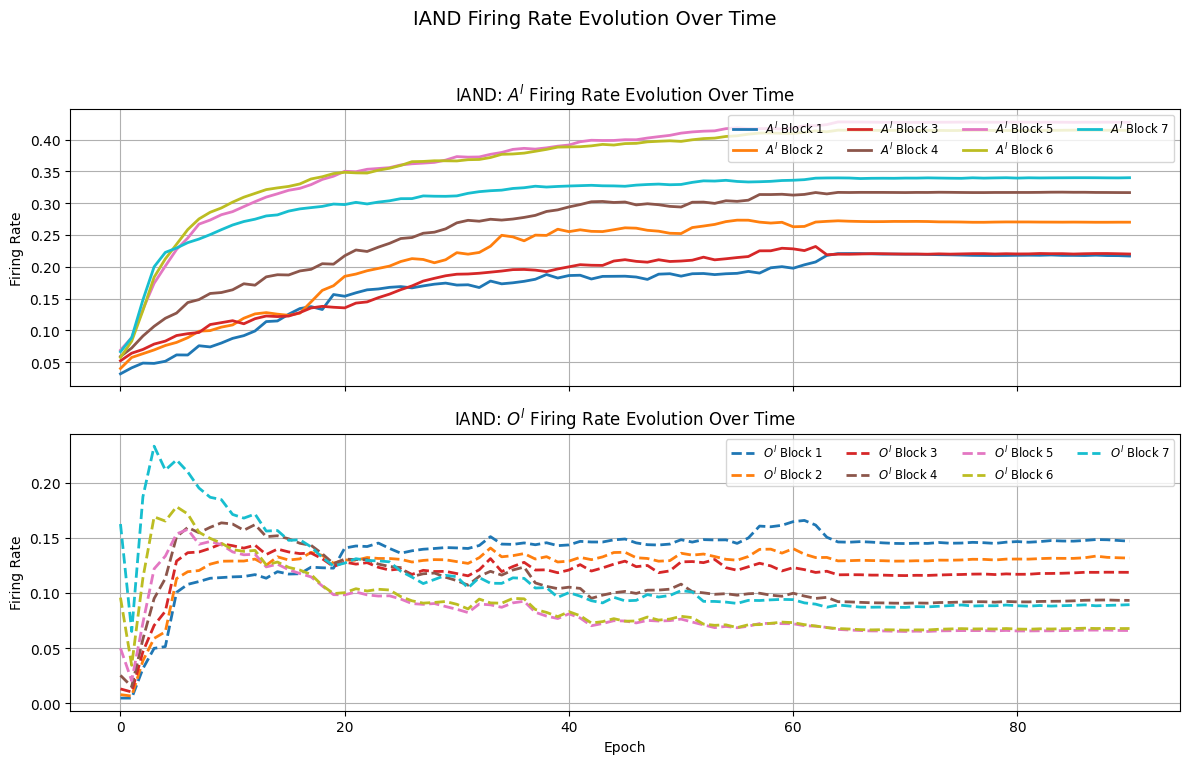

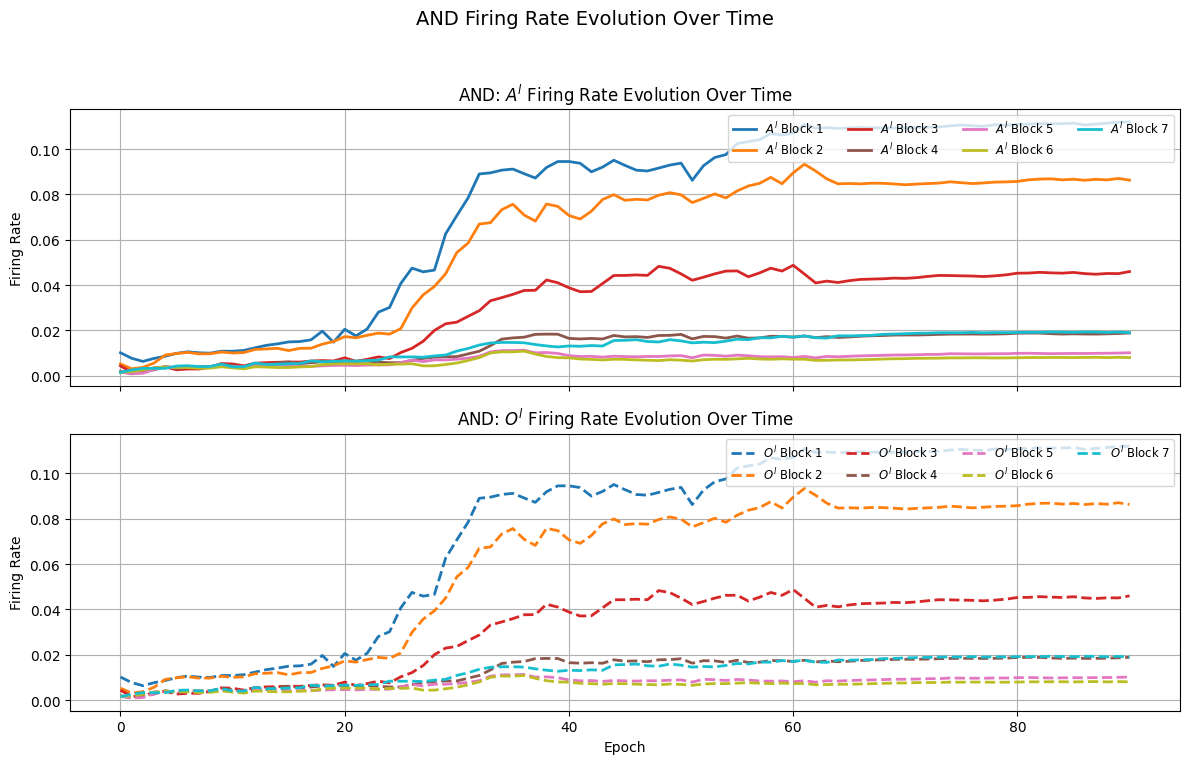

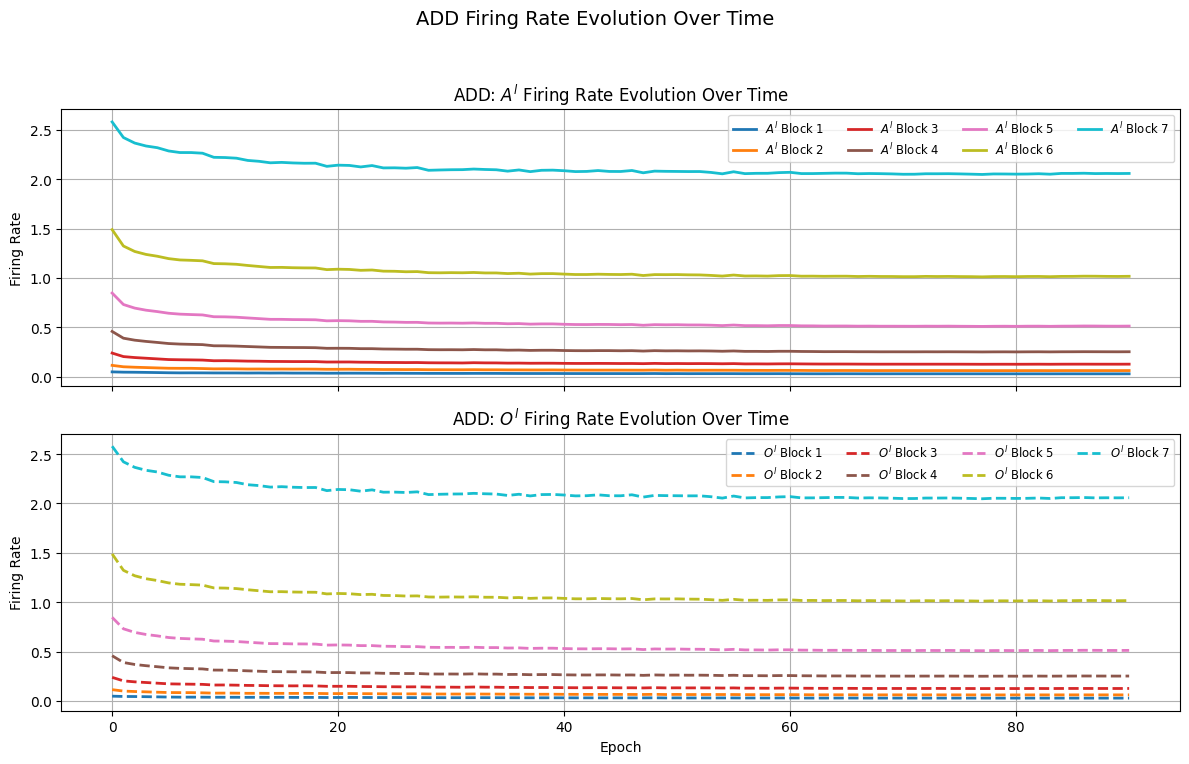

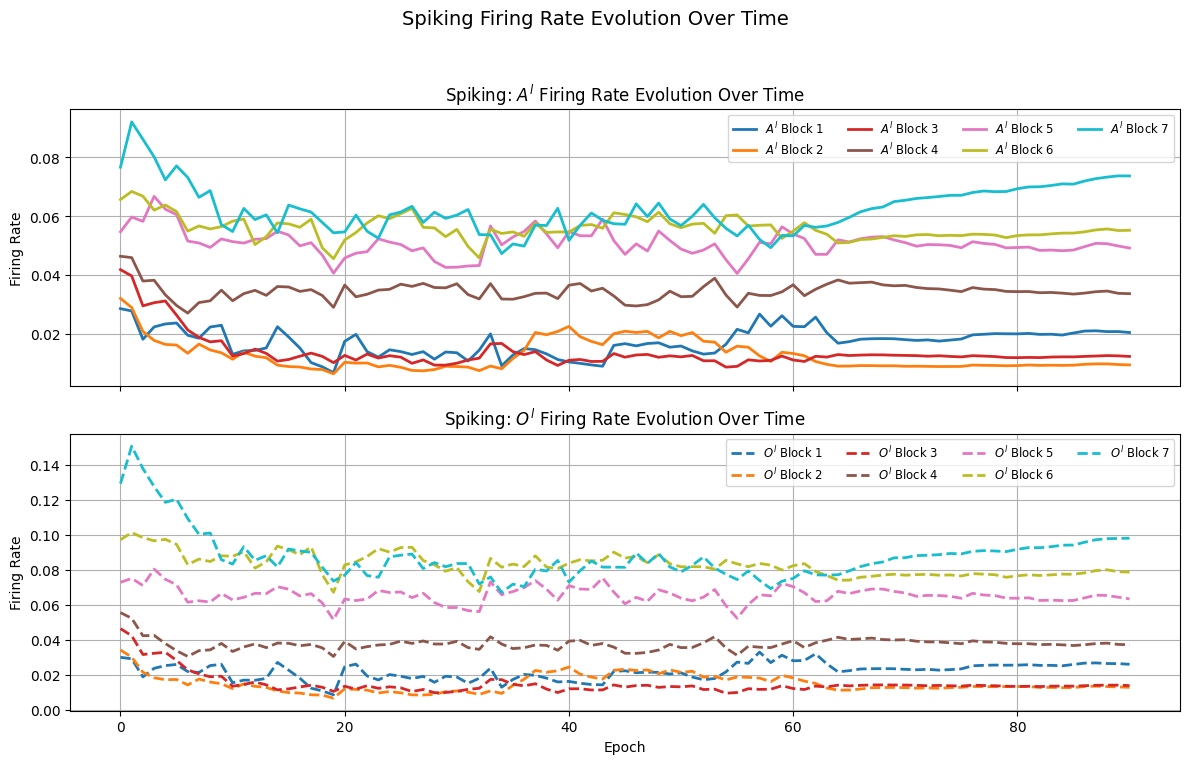

In [20]:
plot_path = PLOT_DIR / "firing_rate_evolution_per_function"
plot_path.mkdir(exist_ok=True)

df_als = [pd.read_csv(al_csv) for al_csv in A_l_csvs]
df_ols = [pd.read_csv(ol_csv) for ol_csv in O_l_csvs]
plot_al_ol_evolution_dual_subplot(df_als, df_ols, plot_path)

In [183]:
def plot_firing_rate_heatmaps_per_model(df_list, rate_type, plot_path):
    blocks = [f'block_{i}' for i in range(1, 8)]
    plot_path = Path(plot_path)
    plot_path.mkdir(parents=True, exist_ok=True)

    for df in df_list:
        model_name = df['connect_f'].unique()[0]
        if not isinstance(model_name, str):
            model_name = "Spiking"

        # Create 2D array: rows = epochs, columns = blocks
        heatmap_data = df[blocks].values

        # Plot heatmap
        fig, ax = plt.subplots(figsize=(8, 6))
        sns.heatmap(
            heatmap_data,
            cmap="viridis",
            cbar_kws={'label': 'Firing Rate'},
            xticklabels=[f'{i}' for i in range(1, 8)],
            yticklabels=10 if heatmap_data.shape[0] > 10 else 1,
            ax=ax
        )

        ax.set_xlabel("Block Index $l$")
        ax.set_ylabel("Epoch")
        ax.set_title(f"{rate_type} Firing Rate Heatmap ({model_name})")
        fig.tight_layout()

        # Save
        fig.savefig(plot_path / f"{rate_type}_heatmap_{model_name}.png", dpi=300)
        plt.show()
        plt.close(fig)

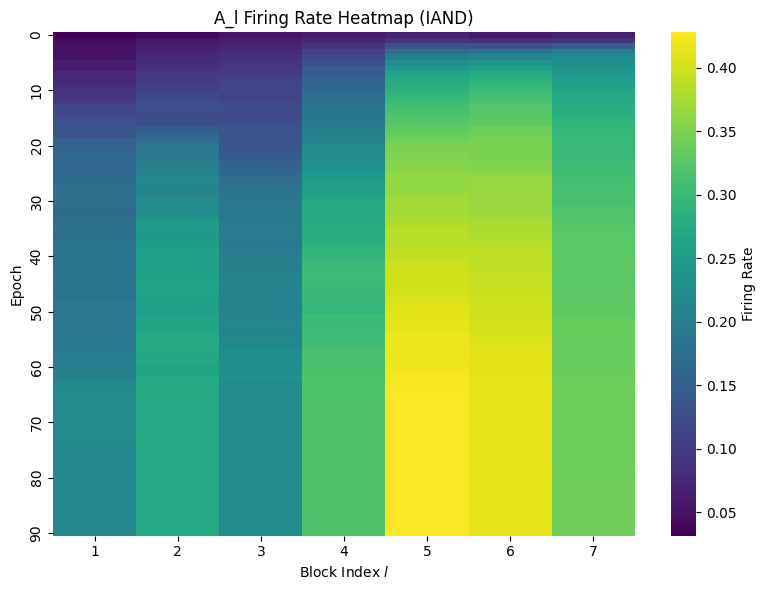

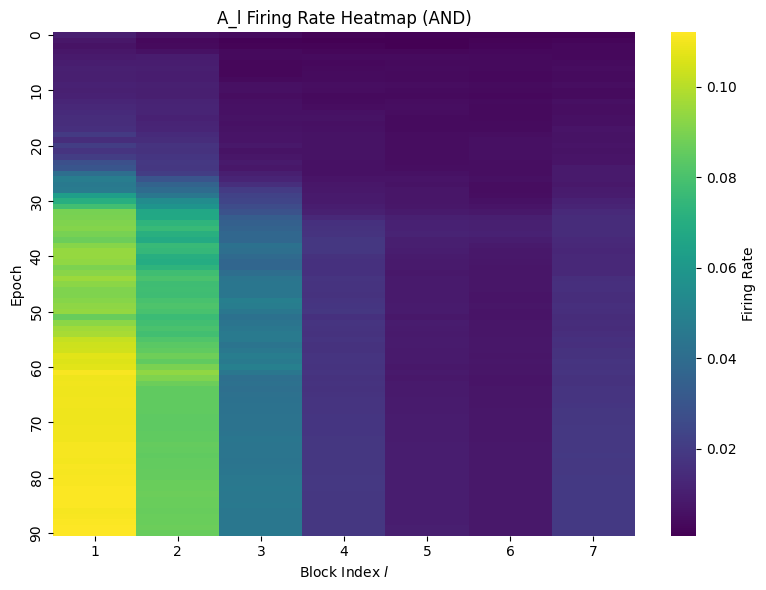

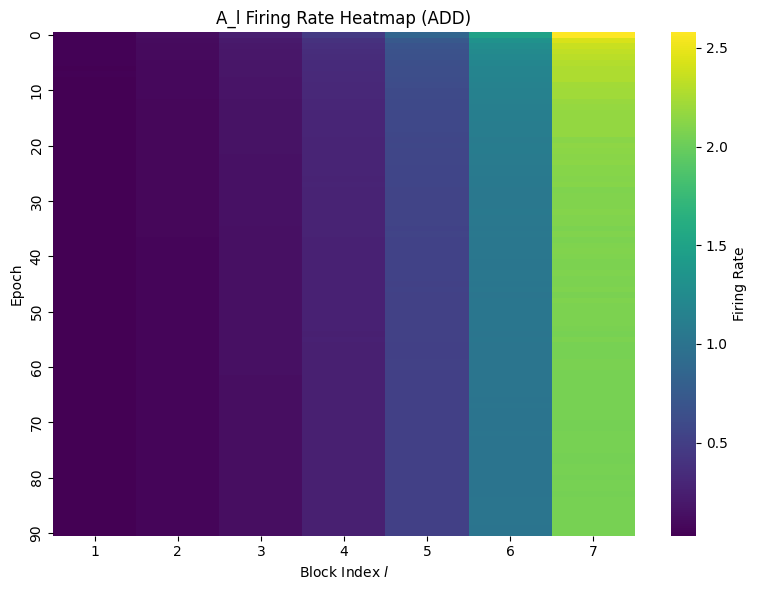

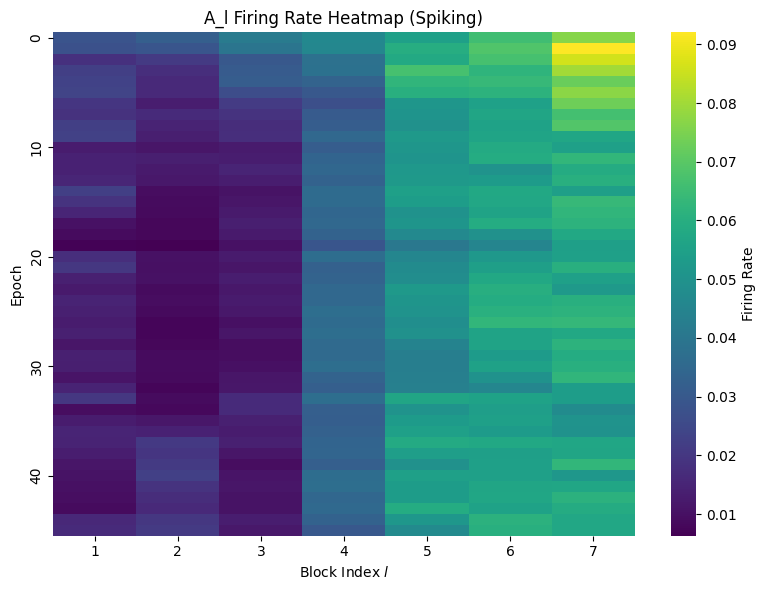

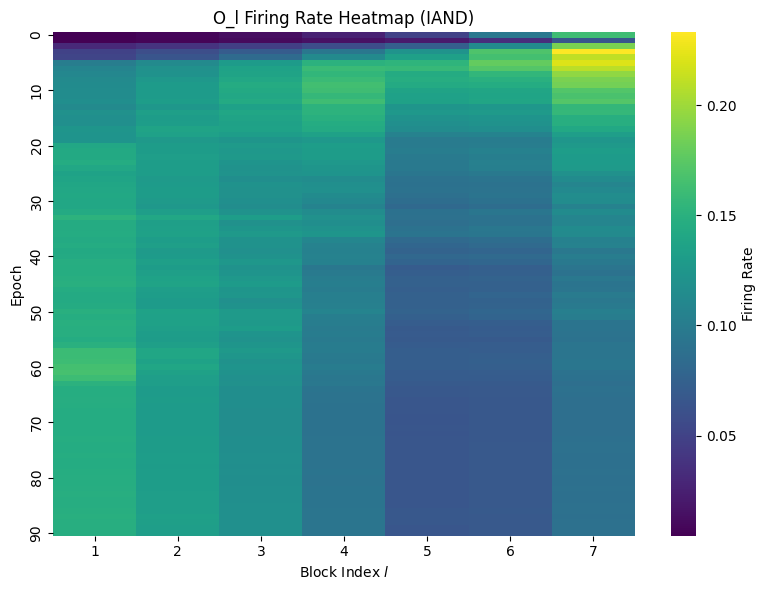

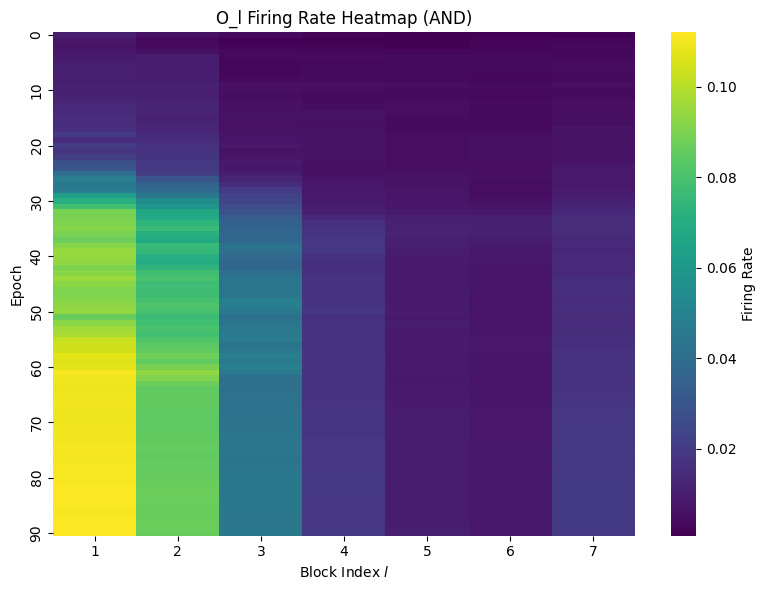

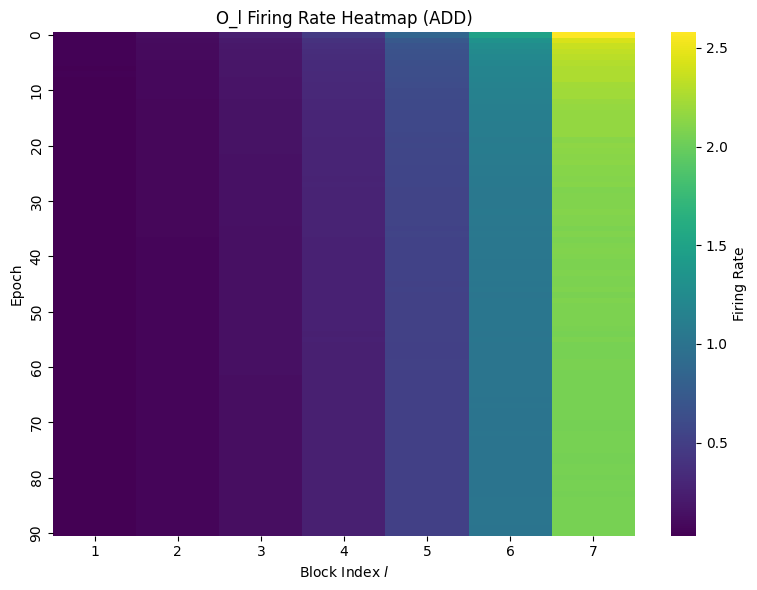

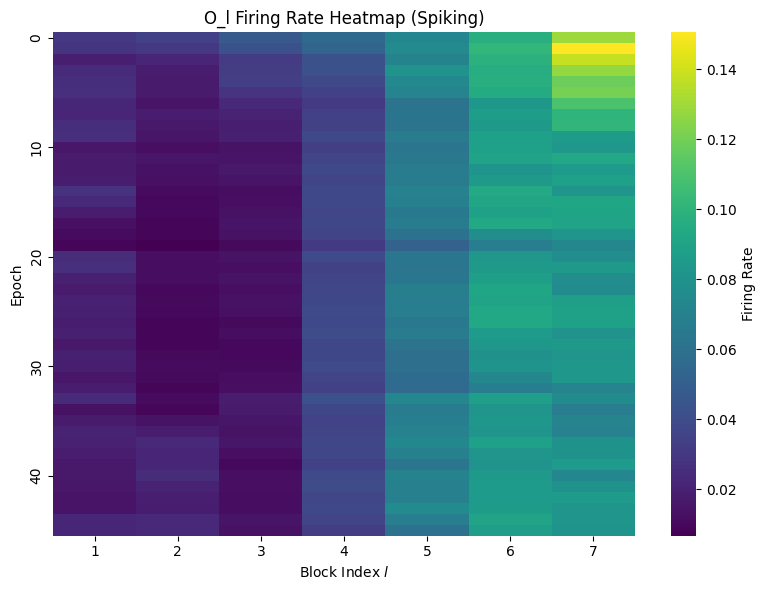

In [185]:
plot_path = PLOT_DIR / "heatmaps"
plot_path.mkdir(exist_ok=True)

df_als = [pd.read_csv(al_csv) for al_csv in A_l_csvs]
df_ols = [pd.read_csv(ol_csv) for ol_csv in O_l_csvs]

plot_firing_rate_heatmaps_per_model(df_als, rate_type="A_l", plot_path=plot_path)
plot_firing_rate_heatmaps_per_model(df_ols, rate_type="O_l", plot_path=plot_path)

In [55]:
def plot_metrics_from_folder(folder_name, plot_path, smoothing=0.6, show_original=True):
    """
    Plots with TensorBoard-like EMA smoothing and optional original (transparent) lines.
    
    Args:
        folder_name (str): e.g., 'train_acc1'
        plot_path (Path): Directory to save plots
        smoothing (float): 0.0 (no smoothing) to 1.0 (max smoothing). Default 0.6.
        show_original (bool): If True, plots raw data with transparency.
    """
    model_styles = {
        'SEW_ADD': {'color': '#1f77b4', 'label': 'SEW (ADD)'},
        'SEW_AND': {'color': '#ff7f0e', 'label': 'SEW (AND)'},
        'SEW_IAND': {'color': '#2ca02c', 'label': 'SEW (IAND)'},
        'Spiking': {'color': '#d62728', 'label': 'Spiking ResNet'},
    }
    
    plt.figure(figsize=(10, 6))
    folder_path = Path('all-logs/logs-for-plotting') / folder_name
    
    for csv_file in folder_path.glob('*.csv'):
        # Parse model type
        filename = csv_file.stem
        if 'SEWResNet' in filename:
            if 'cnf_ADD' in filename: model_type = 'SEW_ADD'
            elif 'cnf_AND' in filename: model_type = 'SEW_AND'
            elif 'cnf_IAND' in filename: model_type = 'SEW_IAND'
        elif 'SpikingResNet' in filename:
            model_type = 'Spiking'
        else:
            continue
        
        df = pd.read_csv(csv_file)
        if 'Value' not in df.columns or 'Step' not in df.columns:
            continue
        
        style = model_styles[model_type]
        
        # Plot original (transparent)
        if show_original:
            plt.plot(df['Step'], df['Value'], 
                     color=style['color'], 
                     alpha=0.2,  # High transparency
                     linewidth=1,
                     label=f'{style["label"]} (Raw)' if not smoothing else None)  # Avoid duplicate labels
        
        # Plot smoothed (solid)
        df['Value_Smoothed'] = df['Value'].ewm(alpha=1.0 - smoothing).mean()
        plt.plot(df['Step'], df['Value_Smoothed'], 
                 color=style['color'], 
                 label=style['label'],
                 linewidth=2)
    
    plt.xlabel('Epoch')
    plt.ylabel(folder_name.replace('_', ' ').title())
    title = f'{folder_name.replace("_", " ").title()}'
    if smoothing: title += f' (EMA α={smoothing})'
    plt.title(title)
    plt.grid(True, linestyle='--', alpha=0.5)
    
    # Handle legend: Only show smoothed lines if raw data is plotted
    handles, labels = plt.gca().get_legend_handles_labels()
    if show_original:
        # Remove duplicate raw data labels (keep only first occurrence)
        seen = set()
        unique_handles = []
        unique_labels = []
        for h, l in zip(handles, labels):
            if l not in seen:
                seen.add(l)
                unique_handles.append(h)
                unique_labels.append(l)
        plt.legend(unique_handles, unique_labels)
    else:
        plt.legend()
    
    plt.tight_layout()
    plt.savefig(plot_path / f'{folder_name}_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

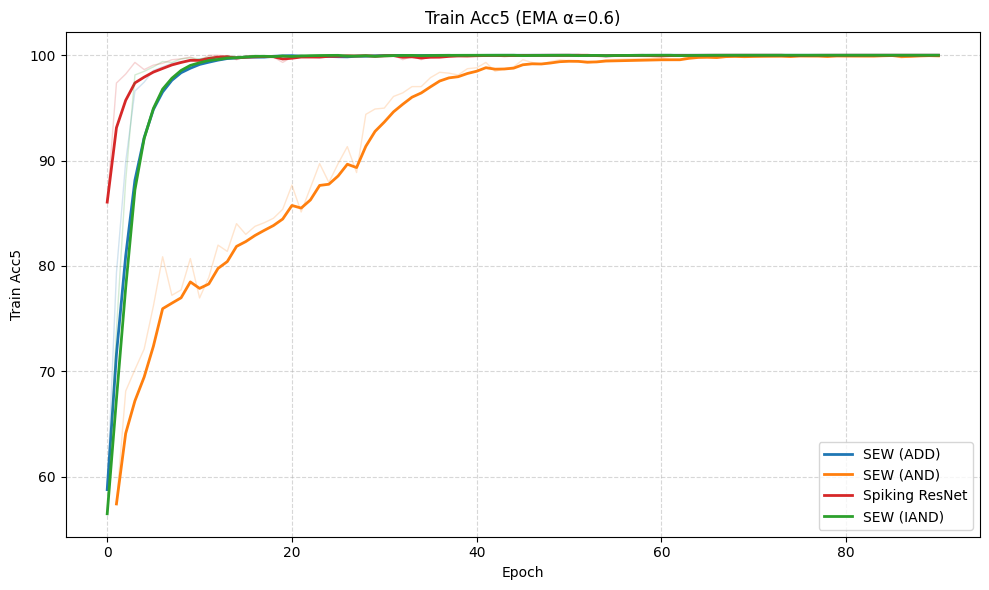

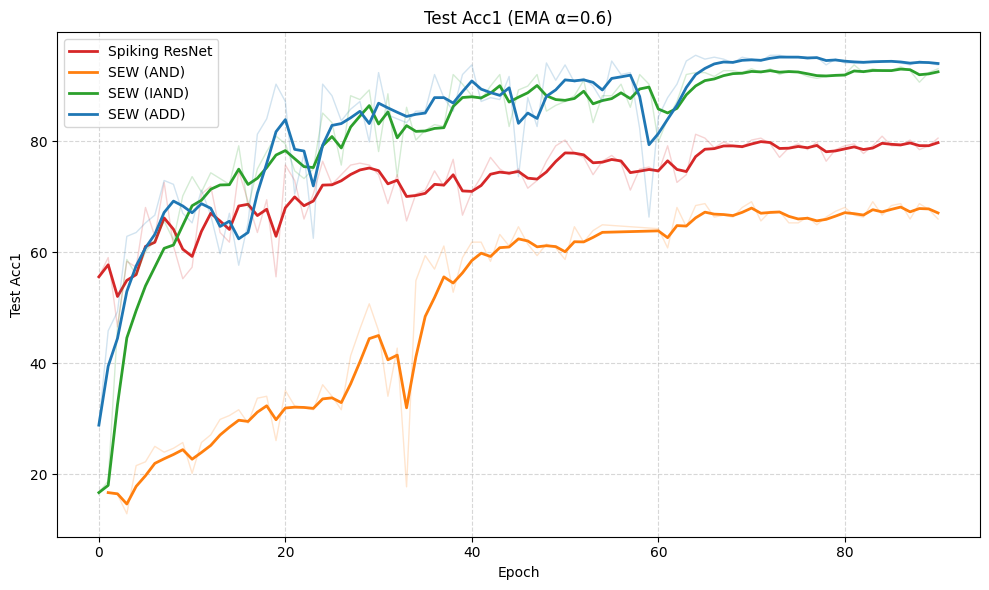

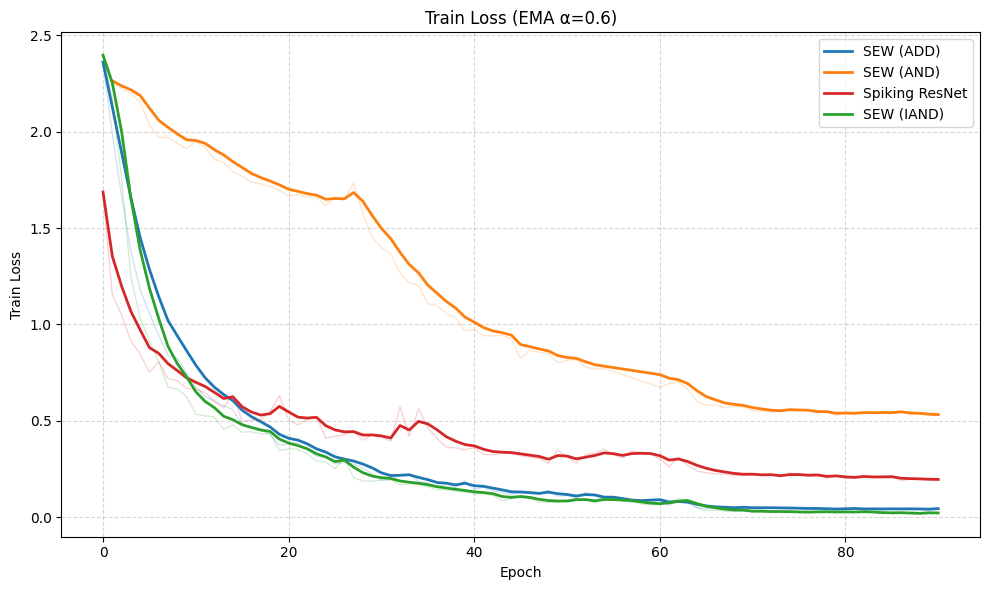

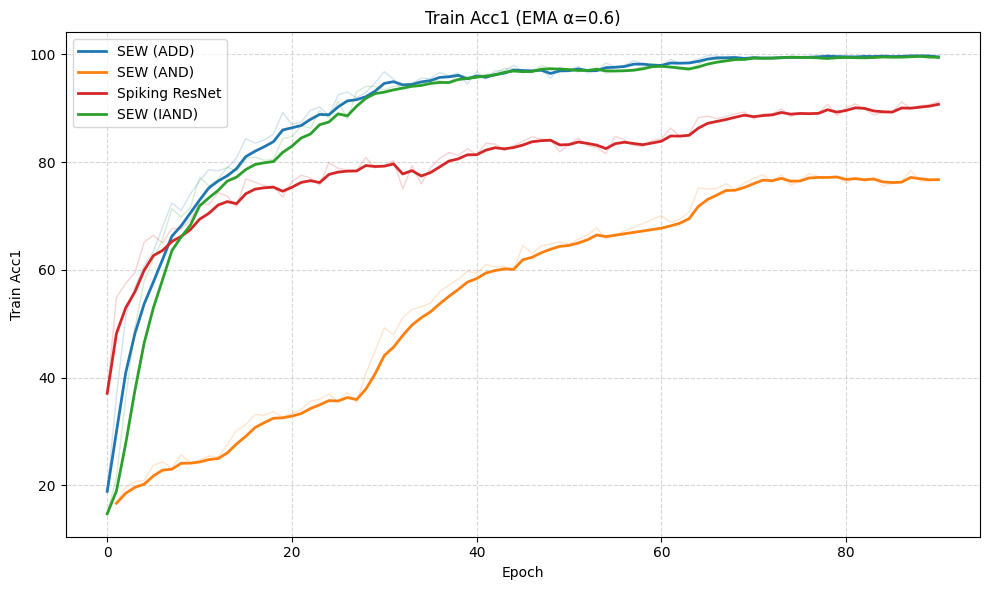

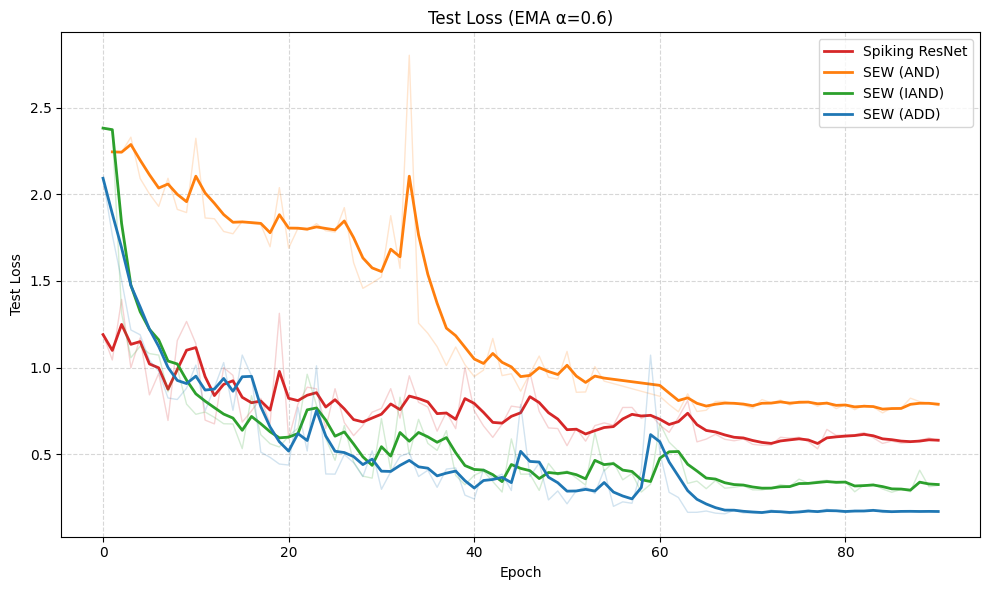

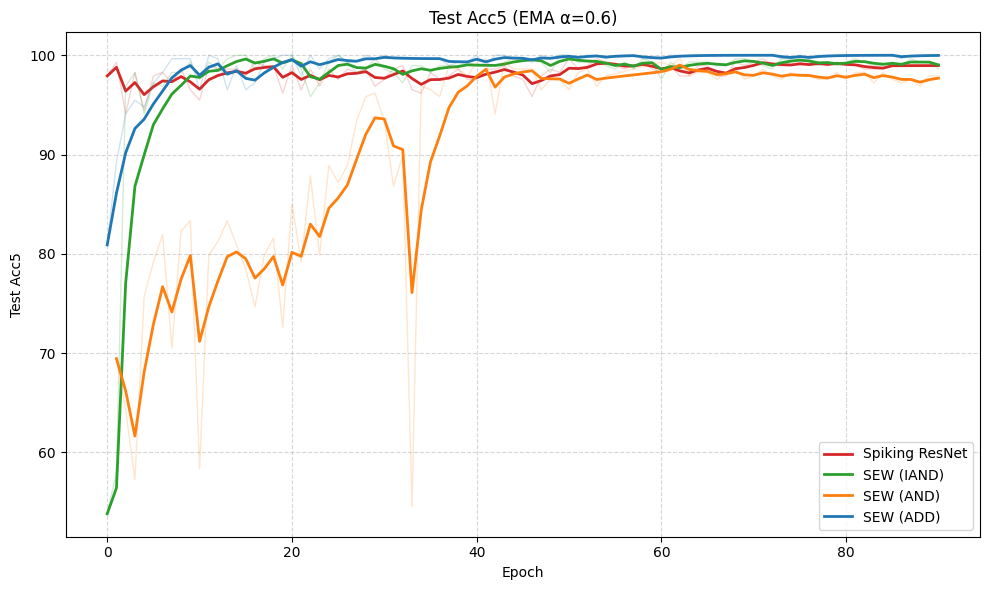

In [56]:
plot_path = PLOT_DIR / "acc_loss_results"
plot_path.mkdir(exist_ok=True)

folder_names = ["train_acc5", "test_acc1", "train_loss", "train_acc1", "test_loss", "test_acc5"]
for folder_name in folder_names:
    plot_metrics_from_folder(folder_name, plot_path, smoothing=0.6)